In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# ── Output directory ─────────────────────────────────────────
PLOTS_DIR = Path('../output/plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Global style ─────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

print(f'Plots will be saved to: {PLOTS_DIR.resolve()}')

Plots will be saved to: C:\Users\LENOVO\Desktop\DeliverIQ\output\plots


In [2]:
df = pd.read_csv('../data/processed/merged/master.csv')

# timestamp_w is a date column — parse it
df['timestamp_w'] = pd.to_datetime(df['timestamp_w'], errors='coerce')

print(f'Shape: {df.shape}')
print(f'\nColumn dtypes:\n{df.dtypes}')
print(f'\nNull counts:\n{df.isnull().sum()}')
print(f'\nDescriptive stats:')
df.describe().T

Shape: (239919, 19)

Column dtypes:
distance_km                 float64
travel_time_min             float64
num_lanes                     int64
num_signals                   int64
hour                        float64
day_of_week                   int64
avg_speed_kmph              float64
temperature_c               float64
visibility_km               float64
timestamp_w          datetime64[ns]
is_rush_hour                  int64
traffic_level_ord           float64
road_highway                  int64
road_residential              int64
road_urban                    int64
weather_clear                 int64
weather_fog                   int64
weather_rain                  int64
log_travel_time             float64
dtype: object

Null counts:
distance_km           1074
travel_time_min          0
num_lanes                0
num_signals              0
hour                     0
day_of_week              0
avg_speed_kmph           0
temperature_c            0
visibility_km            0
timestamp

,count,mean,min,25%,50%,75%,max,std
distance_km,238845.0,53.588511,0.5,1.8,4.33,8.91,3917.644832,301.920132
travel_time_min,239919.0,21.797924,0.26,6.44,12.29,24.17,599.37,40.635117
num_lanes,239919.0,3.095857,1.0,2.0,3.0,4.0,6.0,1.248291
num_signals,239919.0,6.191798,0.0,2.0,6.0,10.0,15.0,4.184504
hour,239919.0,10.940426,0.0,5.0,11.0,17.0,23.0,7.187956
day_of_week,239919.0,3.003968,0.0,1.0,3.0,5.0,6.0,2.015049
avg_speed_kmph,239919.0,43.805417,10.0,28.0,45.5,56.2,80.0,18.292553
temperature_c,239919.0,20.158334,-3.0,15.55,20.15,24.8,53.7,7.646539
visibility_km,239919.0,5.934218,0.02,4.975,6.25,7.025,14.9,1.817511
timestamp_w,215937,2023-04-24 06:34:02.116131072,2023-01-01 00:00:00,2023-02-06 11:37:00,2023-03-30 17:26:00,2023-06-21 00:00:00,2023-12-31 23:34:00,NaN


In [3]:
def save_fig(fig, filename):
    """Save figure to PLOTS_DIR and display it."""
    path = PLOTS_DIR / filename
    fig.savefig(path, dpi=120, bbox_inches='tight')
    print(f'Saved → {path.name}')
    plt.show()
    plt.close(fig)

In [4]:
# road_type
def decode_road_type(row):
    if row['road_highway'] == 1:
        return 'highway'
    elif row['road_residential'] == 1:
        return 'residential'
    elif row['road_urban'] == 1:
        return 'urban'
    return 'unknown'

# weather_type
def decode_weather_type(row):
    if row['weather_clear'] == 1:
        return 'clear'
    elif row['weather_fog'] == 1:
        return 'fog'
    elif row['weather_rain'] == 1:
        return 'rain'
    return 'unknown'

# traffic_level
traffic_map = {0.0: 'low', 1.0: 'medium', 2.0: 'high'}

df['road_type']      = df.apply(decode_road_type, axis=1)
df['weather_type']   = df.apply(decode_weather_type, axis=1)
df['traffic_level']  = df['traffic_level_ord'].map(traffic_map)

print('Decoded label value counts:')
print(df['road_type'].value_counts())
print(df['weather_type'].value_counts())
print(df['traffic_level'].value_counts())

Decoded label value counts:
road_type
residential    83603
urban          72458
highway        51306
unknown        32552
Name: count, dtype: int64
weather_type
clear      172051
unknown     24717
rain        21690
fog         21461
Name: count, dtype: int64
traffic_level
low       78387
medium    70102
high      58660
Name: count, dtype: int64


Target skewness: 8.466
Log-transform RECOMMENDED (|skewness| > 1.0)
Saved → 01_target_distribution.png


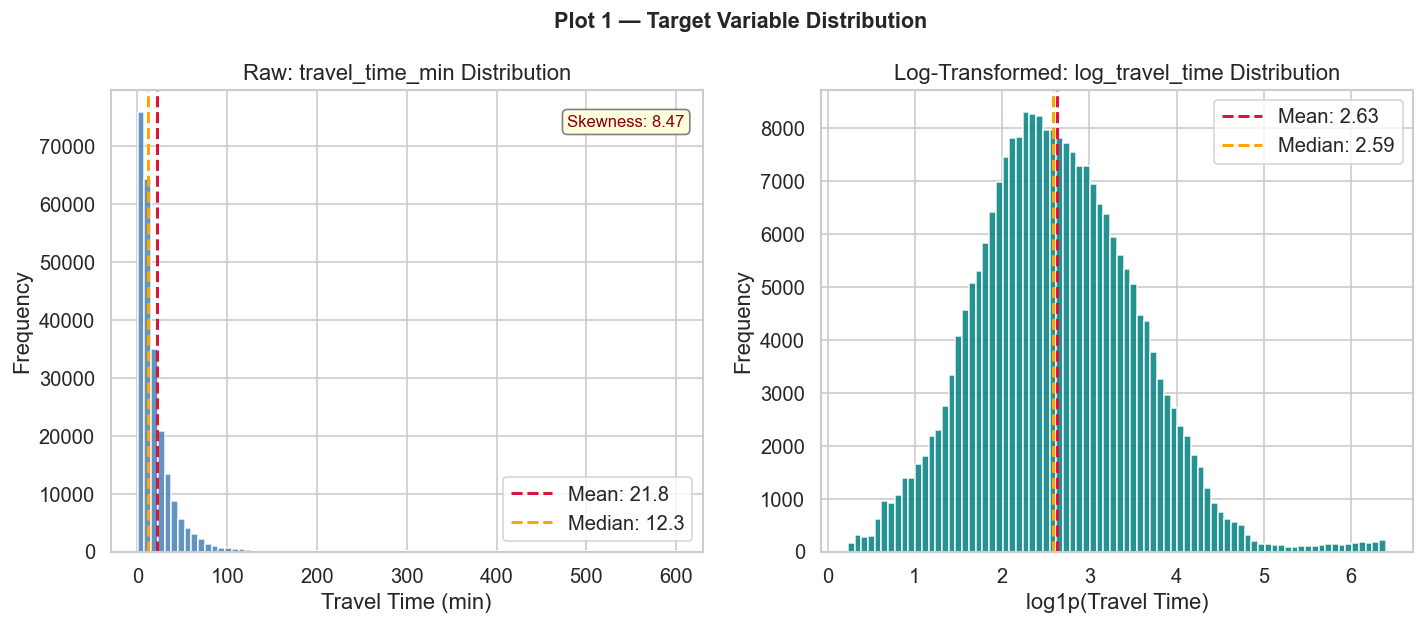

In [5]:
# ── Hypothesis: travel_time_min is right-skewed ──────────────
from scipy import stats

skewness = stats.skew(df['travel_time_min'].dropna())
print(f'Target skewness: {skewness:.3f}')
print(f'Log-transform {"RECOMMENDED" if abs(skewness) > 1.0 else "NOT required"} (|skewness| > 1.0)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw
axes[0].hist(df['travel_time_min'], bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Travel Time (min)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Raw: travel_time_min Distribution')
axes[0].axvline(df['travel_time_min'].mean(),   color='crimson', lw=1.8, linestyle='--', label=f'Mean: {df["travel_time_min"].mean():.1f}')
axes[0].axvline(df['travel_time_min'].median(), color='orange',  lw=1.8, linestyle='--', label=f'Median: {df["travel_time_min"].median():.1f}')
axes[0].legend()
axes[0].text(0.97, 0.92, f'Skewness: {skewness:.2f}', transform=axes[0].transAxes,
             ha='right', fontsize=10, color='darkred',
             bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='gray'))

# Log-transformed
log_vals = df['log_travel_time'].dropna()
axes[1].hist(log_vals, bins=80, color='teal', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('log1p(Travel Time)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Log-Transformed: log_travel_time Distribution')
axes[1].axvline(log_vals.mean(),   color='crimson', lw=1.8, linestyle='--', label=f'Mean: {log_vals.mean():.2f}')
axes[1].axvline(log_vals.median(), color='orange',  lw=1.8, linestyle='--', label=f'Median: {log_vals.median():.2f}')
axes[1].legend()

fig.suptitle('Plot 1 — Target Variable Distribution', fontsize=13, fontweight='bold', y=1.01)
save_fig(fig, '01_target_distribution.png')

Saved → 02_travel_time_by_road_type.png


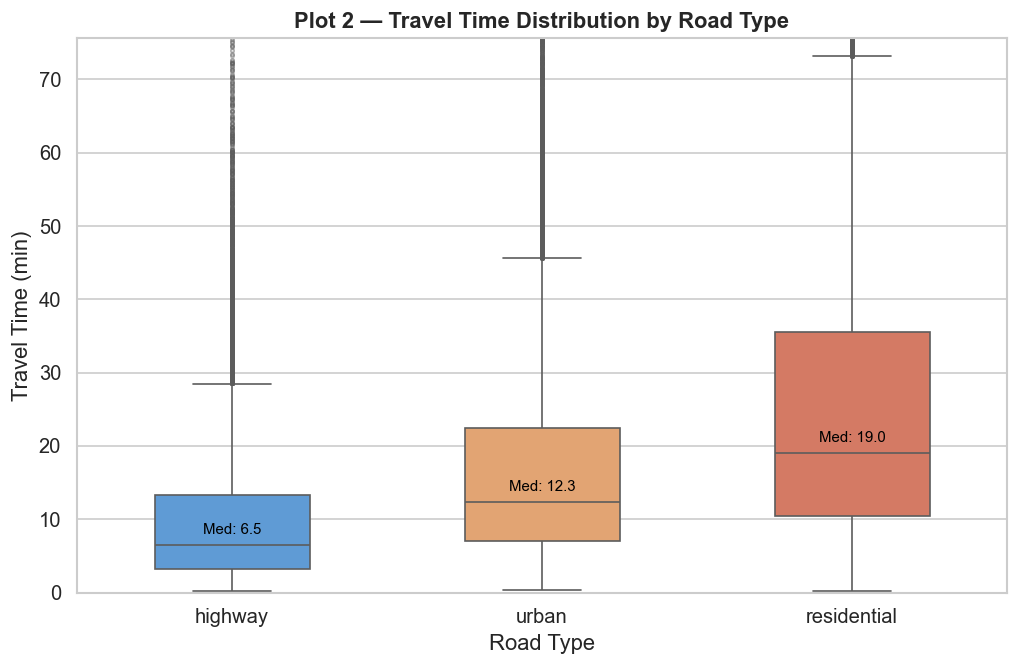

In [6]:
# ── Hypothesis: highway < urban < residential in travel time ─
order = ['highway', 'urban', 'residential']
palette = {'highway': '#4C9BE8', 'urban': '#F4A261', 'residential': '#E76F51'}

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df[df['road_type'] != 'unknown'],
    x='road_type', y='travel_time_min',
    order=order, palette=palette,
    width=0.5, fliersize=2, flierprops=dict(alpha=0.2),
    ax=ax
)

medians = df.groupby('road_type')['travel_time_min'].median()
for i, rt in enumerate(order):
    ax.text(i, medians[rt] + 1.5, f'Med: {medians[rt]:.1f}', ha='center', fontsize=9, color='black')

ax.set_xlabel('Road Type')
ax.set_ylabel('Travel Time (min)')
ax.set_title('Plot 2 — Travel Time Distribution by Road Type', fontweight='bold')
ax.set_ylim(0, df['travel_time_min'].quantile(0.97))

save_fig(fig, '02_travel_time_by_road_type.png')

Saved → 03_heatmap_hour_dow.png


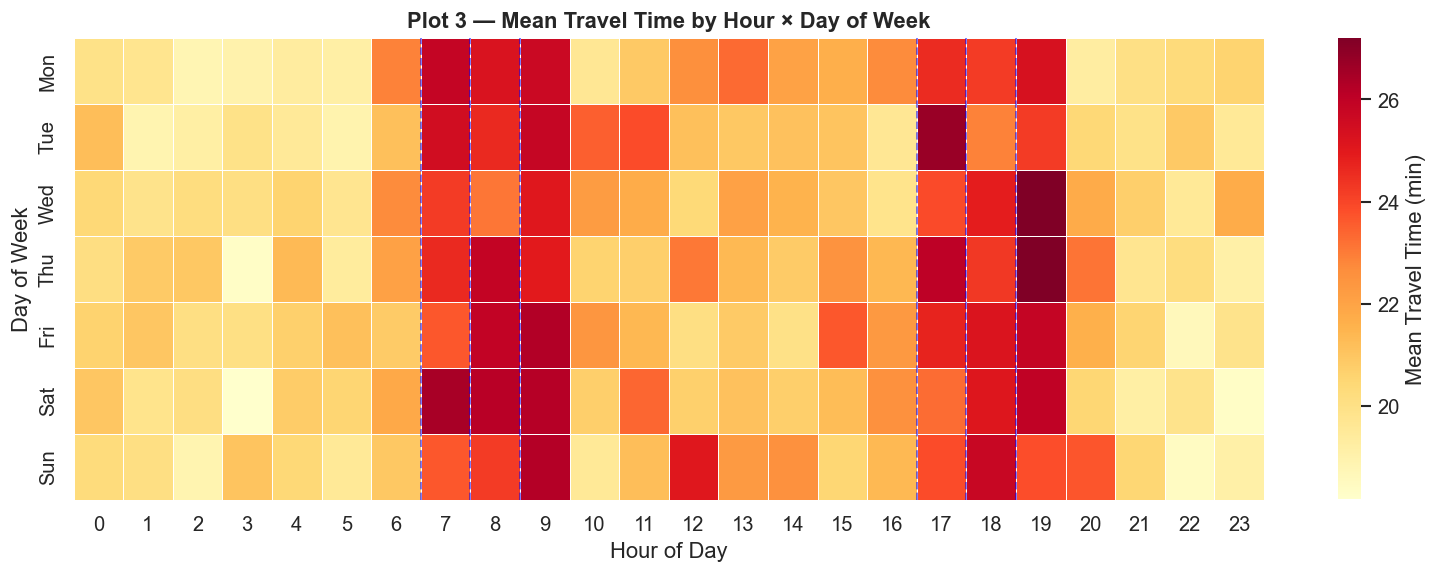

In [7]:
# ── Hypothesis: rush hours (7–9, 17–19) on weekdays are hottest ─
pivot = (
    df.dropna(subset=['hour', 'day_of_week'])
    .groupby(['day_of_week', 'hour'])['travel_time_min']
    .mean()
    .unstack(level='hour')
)

# Ensure all hours 0–23 are present
pivot = pivot.reindex(columns=range(24), fill_value=np.nan)
pivot.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    pivot, annot=False, fmt='.0f',
    cmap='YlOrRd', linewidths=0.3,
    cbar_kws={'label': 'Mean Travel Time (min)'},
    ax=ax
)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
ax.set_title('Plot 3 — Mean Travel Time by Hour × Day of Week', fontweight='bold')

# Mark rush hour columns
for h in [7, 8, 9, 17, 18, 19]:
    if h < pivot.shape[1]:
        ax.axvline(x=list(range(24)).index(h), color='blue', lw=1.2, alpha=0.5, linestyle='--')

save_fig(fig, '03_heatmap_hour_dow.png')

Saved → 04_speed_by_traffic_level.png


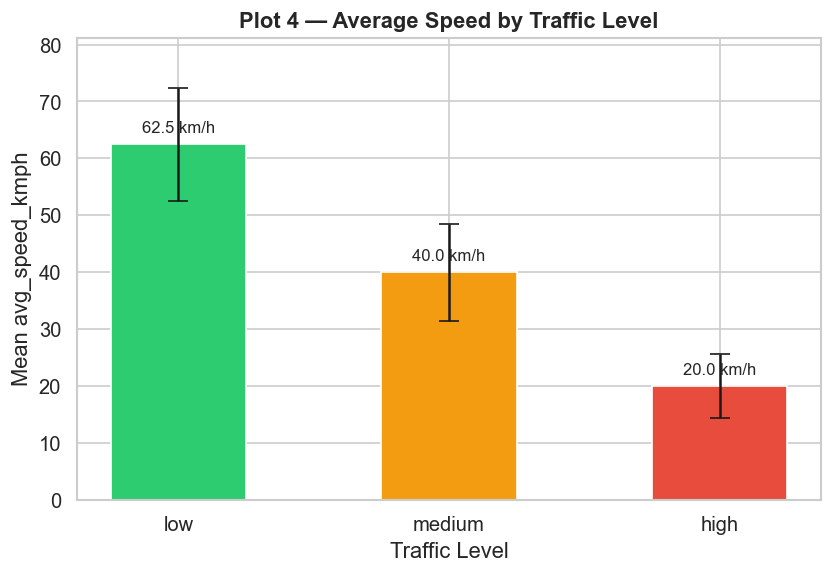

In [8]:
# ── Hypothesis: low < medium < high in avg_speed (monotone) ──
order_tl = ['low', 'medium', 'high']
speed_stats = (
    df[df['traffic_level'].isin(order_tl)]
    .groupby('traffic_level')['avg_speed_kmph']
    .agg(['mean', 'std'])
    .reindex(order_tl)
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    order_tl, speed_stats['mean'],
    yerr=speed_stats['std'],
    color=['#2ECC71', '#F39C12', '#E74C3C'],
    edgecolor='white', capsize=6, width=0.5
)

for bar, val in zip(bars, speed_stats['mean']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f'{val:.1f} km/h', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Traffic Level')
ax.set_ylabel('Mean avg_speed_kmph')
ax.set_title('Plot 4 — Average Speed by Traffic Level', fontweight='bold')
ax.set_ylim(0, speed_stats['mean'].max() * 1.3)

save_fig(fig, '04_speed_by_traffic_level.png')

Saved → 05_distance_vs_traveltime_traffic.png


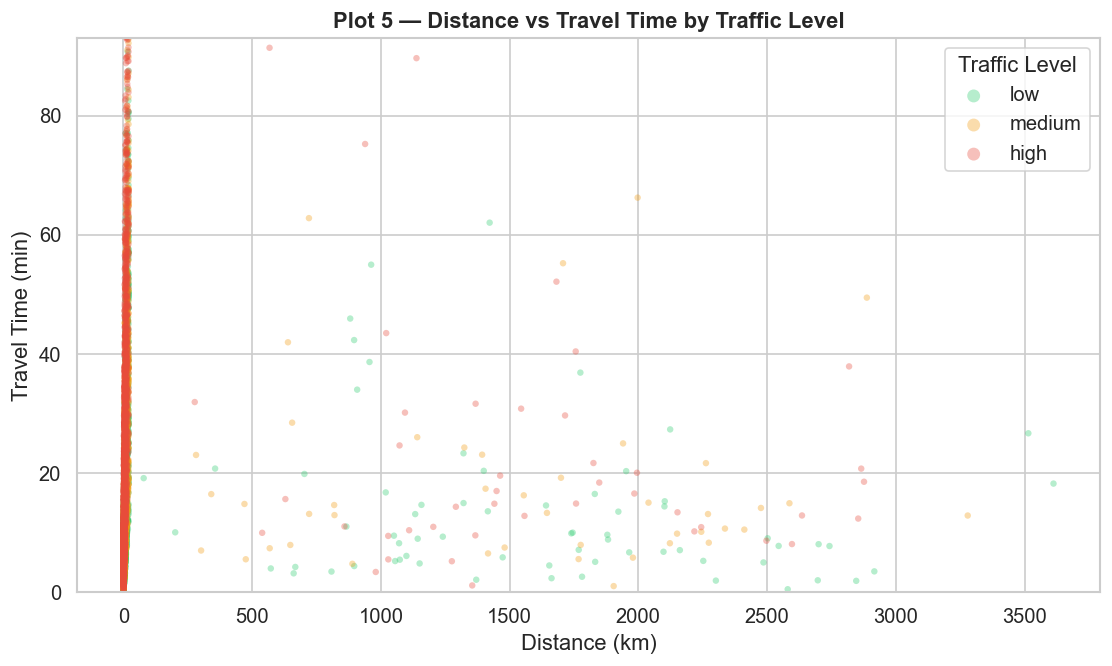

In [9]:
# ── Hypothesis: relationship is roughly linear but non-linearly split by traffic ─
sample = df[df['traffic_level'].isin(['low', 'medium', 'high'])].sample(8000, random_state=42)

color_map = {'low': '#2ECC71', 'medium': '#F39C12', 'high': '#E74C3C'}
order_tl   = ['low', 'medium', 'high']

fig, ax = plt.subplots(figsize=(11, 6))
for level in order_tl:
    sub = sample[sample['traffic_level'] == level]
    ax.scatter(sub['distance_km'], sub['travel_time_min'],
               c=color_map[level], label=level, alpha=0.35, s=15, edgecolors='none')

ax.set_xlabel('Distance (km)')
ax.set_ylabel('Travel Time (min)')
ax.set_title('Plot 5 — Distance vs Travel Time by Traffic Level', fontweight='bold')
ax.set_ylim(0, df['travel_time_min'].quantile(0.98))
ax.legend(title='Traffic Level', markerscale=2)

save_fig(fig, '05_distance_vs_traveltime_traffic.png')

Saved → 06_travel_time_by_weather.png


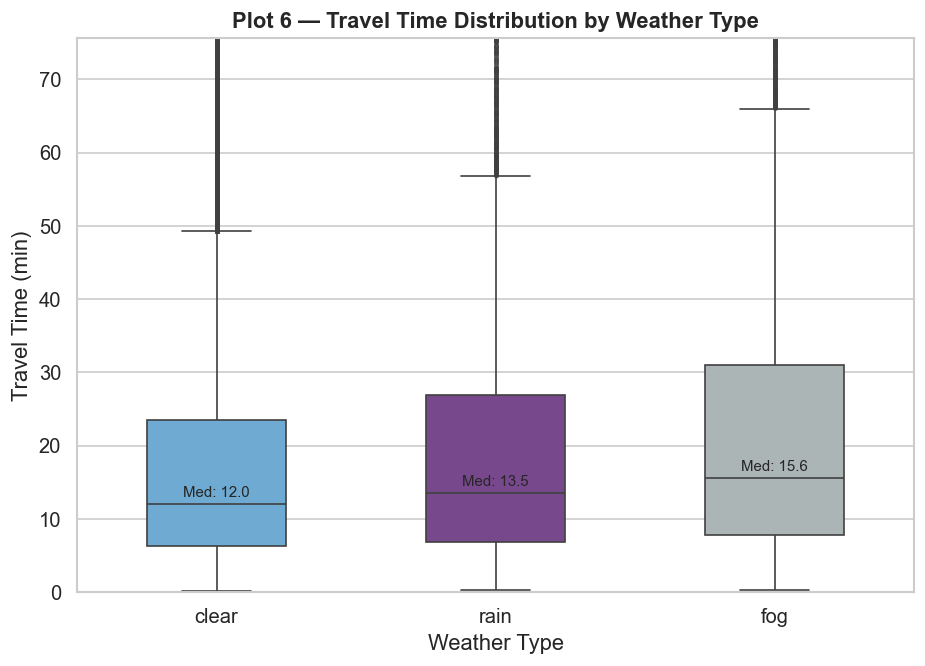

In [10]:
# ── Hypothesis: fog > rain > clear in travel time ──────────
order_wt = ['clear', 'rain', 'fog']
palette_wt = {'clear': '#5DADE2', 'rain': '#7D3C98', 'fog': '#AAB7B8'}

fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(
    data=df[df['weather_type'].isin(order_wt)],
    x='weather_type', y='travel_time_min',
    order=order_wt, palette=palette_wt,
    width=0.5, fliersize=2, flierprops=dict(alpha=0.2),
    ax=ax
)

medians_wt = df[df['weather_type'].isin(order_wt)].groupby('weather_type')['travel_time_min'].median()
for i, wt in enumerate(order_wt):
    ax.text(i, medians_wt[wt] + 1.0, f'Med: {medians_wt[wt]:.1f}', ha='center', fontsize=9)

ax.set_ylim(0, df['travel_time_min'].quantile(0.97))
ax.set_xlabel('Weather Type')
ax.set_ylabel('Travel Time (min)')
ax.set_title('Plot 6 — Travel Time Distribution by Weather Type', fontweight='bold')

save_fig(fig, '06_travel_time_by_weather.png')

Saved → 07_correlation_heatmap.png


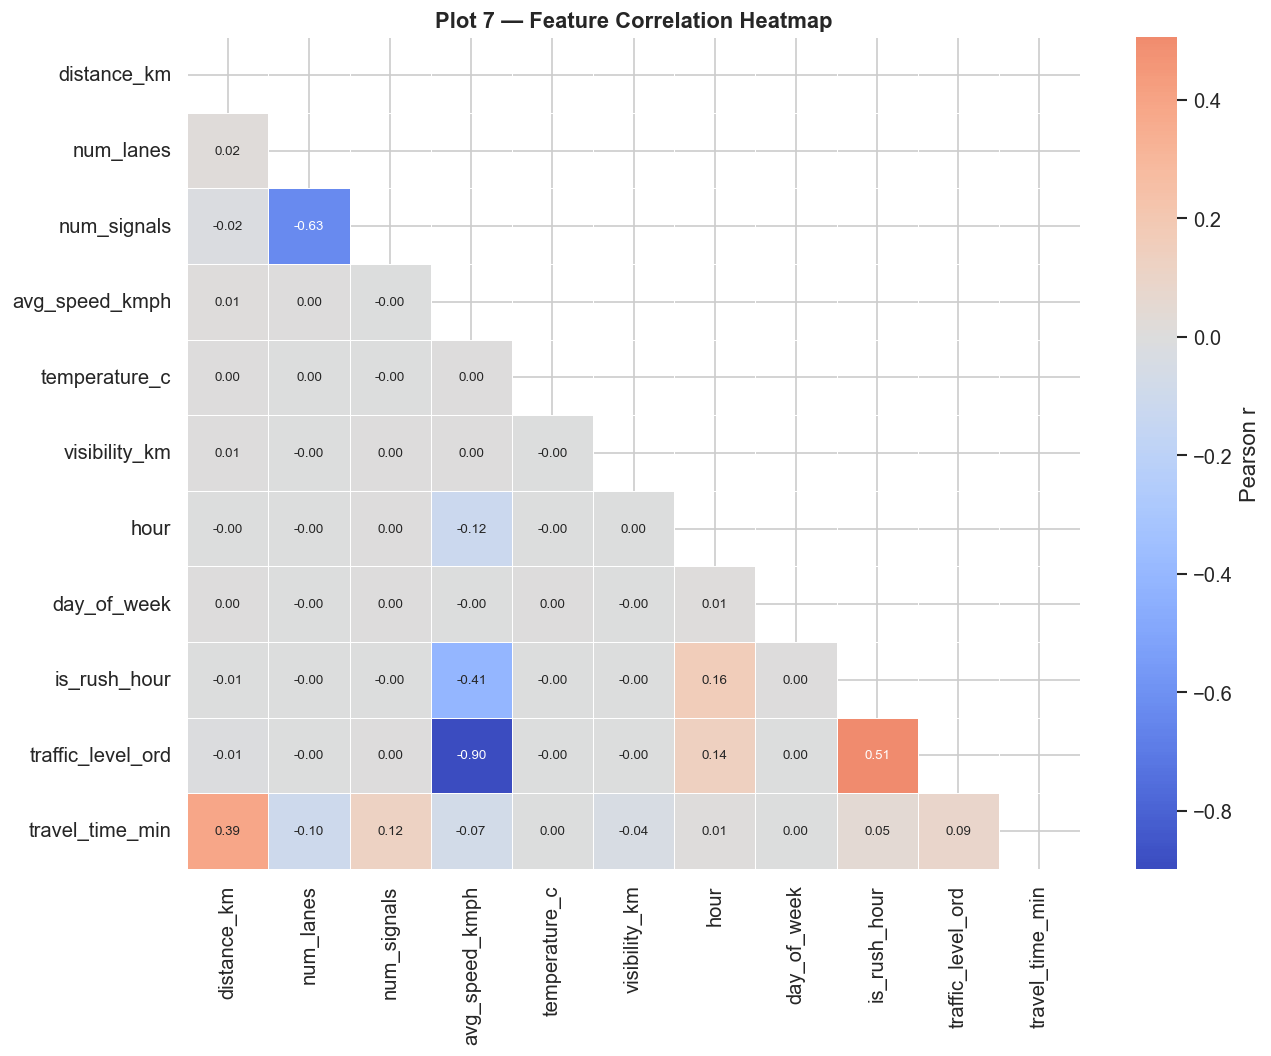

In [11]:
# ── Hypothesis: distance_km has highest correlation with target ─
num_cols = [
    'distance_km', 'num_lanes', 'num_signals',
    'avg_speed_kmph', 'temperature_c', 'visibility_km',
    'hour', 'day_of_week', 'is_rush_hour',
    'traffic_level_ord', 'travel_time_min'
]

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 8},
    cbar_kws={'label': 'Pearson r'},
    ax=ax
)
ax.set_title('Plot 7 — Feature Correlation Heatmap', fontweight='bold')

save_fig(fig, '07_correlation_heatmap.png')

Saved → 08_violin_speed_rush_hour.png


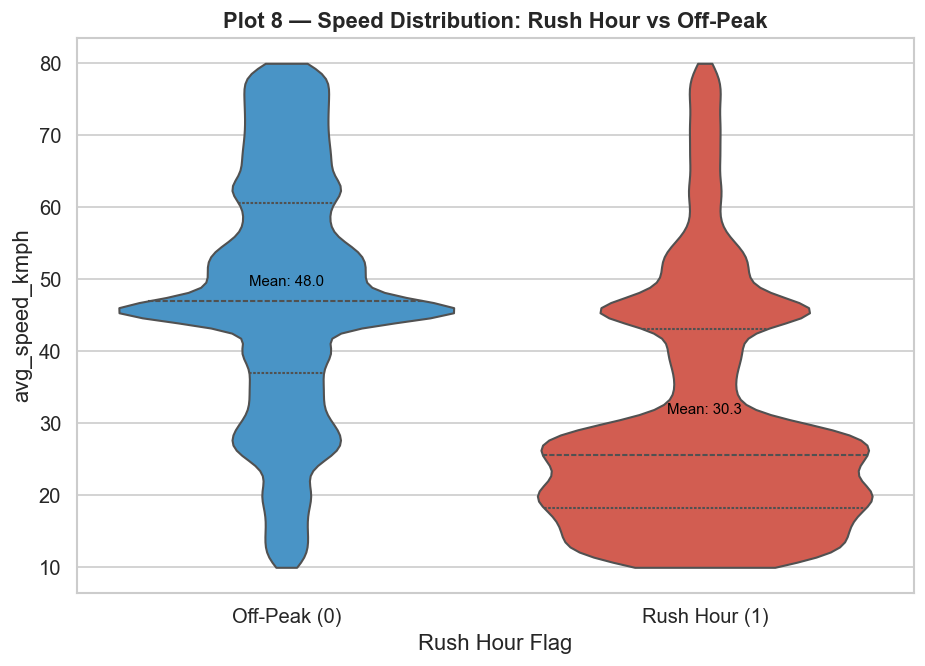

In [12]:
# ── Hypothesis: rush hour (1) → lower avg_speed_kmph and more variance ─
fig, ax = plt.subplots(figsize=(9, 6))

rush_labels = {0: 'Off-Peak (0)', 1: 'Rush Hour (1)'}
plot_df = df[df['avg_speed_kmph'].notna()].copy()
plot_df['rush_label'] = plot_df['is_rush_hour'].map(rush_labels)

sns.violinplot(
    data=plot_df,
    x='rush_label', y='avg_speed_kmph',
    order=['Off-Peak (0)', 'Rush Hour (1)'],
    palette=['#3498DB', '#E74C3C'],
    inner='quartile', cut=0, ax=ax
)

means = plot_df.groupby('rush_label')['avg_speed_kmph'].mean()
for i, label in enumerate(['Off-Peak (0)', 'Rush Hour (1)']):
    ax.text(i, means[label] + 1, f'Mean: {means[label]:.1f}', ha='center', fontsize=9, color='black')

ax.set_xlabel('Rush Hour Flag')
ax.set_ylabel('avg_speed_kmph')
ax.set_title('Plot 8 — Speed Distribution: Rush Hour vs Off-Peak', fontweight='bold')

save_fig(fig, '08_violin_speed_rush_hour.png')

Saved → 09_trip_count_by_hour.png


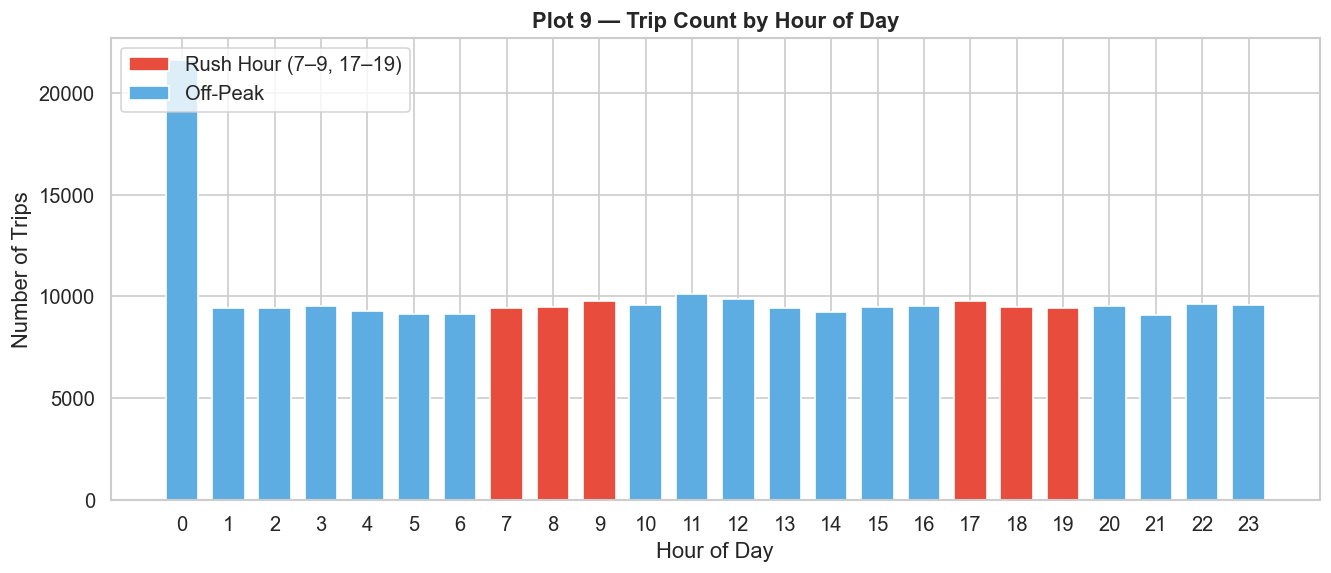

In [13]:
# ── Hypothesis: peaks at 7–9 AM and 17–19 PM ────────────────
hour_counts = df['hour'].dropna().astype(int).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(13, 5))
colors = ['#E74C3C' if h in [7, 8, 9, 17, 18, 19] else '#5DADE2' for h in hour_counts.index]
ax.bar(hour_counts.index, hour_counts.values, color=colors, edgecolor='white', width=0.7)

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Trips')
ax.set_title('Plot 9 — Trip Count by Hour of Day', fontweight='bold')
ax.set_xticks(range(24))

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E74C3C', label='Rush Hour (7–9, 17–19)'),
    Patch(facecolor='#5DADE2', label='Off-Peak'),
]
ax.legend(handles=legend_elements, loc='upper left')

save_fig(fig, '09_trip_count_by_hour.png')

Saved → 10_travel_time_road_x_weather.png


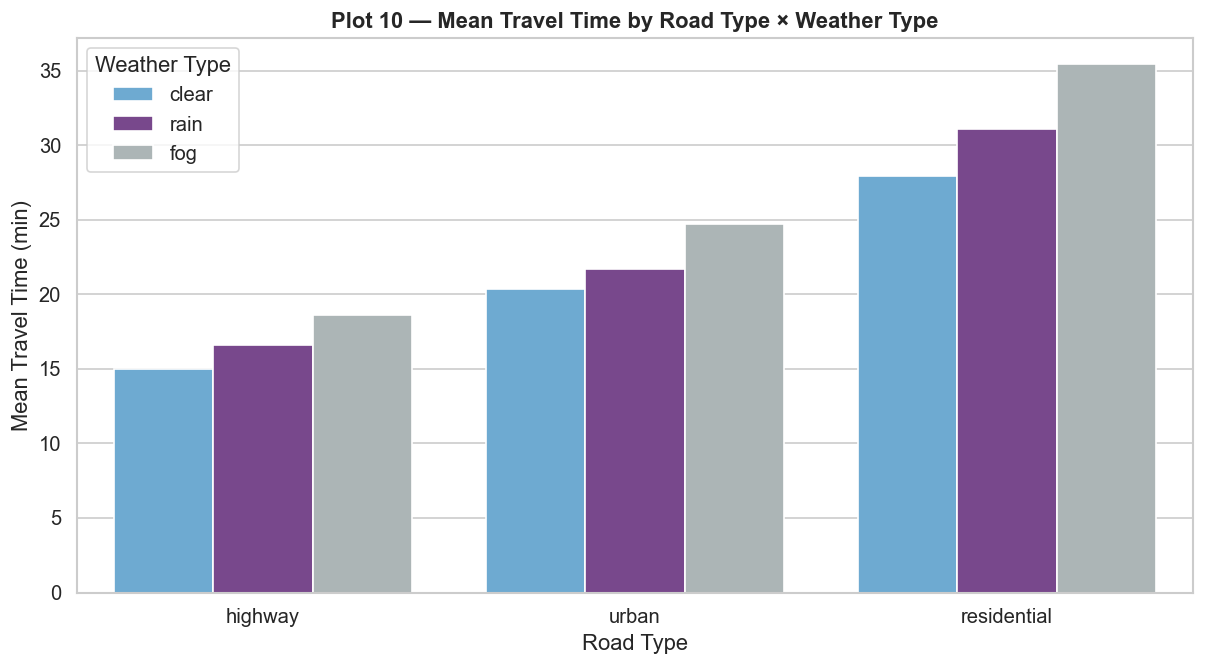

In [14]:
# ── Hypothesis: fog + residential = worst combination ────────
plot_df = df[
    df['road_type'].isin(['highway', 'urban', 'residential']) &
    df['weather_type'].isin(['clear', 'rain', 'fog'])
].copy()

grouped = (
    plot_df.groupby(['road_type', 'weather_type'])['travel_time_min']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=grouped,
    x='road_type', y='travel_time_min', hue='weather_type',
    order=['highway', 'urban', 'residential'],
    hue_order=['clear', 'rain', 'fog'],
    palette={'clear': '#5DADE2', 'rain': '#7D3C98', 'fog': '#AAB7B8'},
    edgecolor='white', ax=ax
)

ax.set_xlabel('Road Type')
ax.set_ylabel('Mean Travel Time (min)')
ax.set_title('Plot 10 — Mean Travel Time by Road Type × Weather Type', fontweight='bold')
ax.legend(title='Weather Type')

save_fig(fig, '10_travel_time_road_x_weather.png')

In [15]:
# This cell is a summary — run after all plots are generated

skewness = stats.skew(df['travel_time_min'].dropna())

rush_mean     = df[df['is_rush_hour'] == 1]['travel_time_min'].mean()
offpeak_mean  = df[df['is_rush_hour'] == 0]['travel_time_min'].mean()
rush_pct_diff = (rush_mean - offpeak_mean) / offpeak_mean * 100

fog_mean   = df[df['weather_type'] == 'fog']['travel_time_min'].mean()
clear_mean = df[df['weather_type'] == 'clear']['travel_time_min'].mean()
fog_pct    = (fog_mean - clear_mean) / clear_mean * 100

res_med  = df[df['road_type'] == 'residential']['travel_time_min'].median()
hwy_med  = df[df['road_type'] == 'highway']['travel_time_min'].median()

dist_corr = df[['distance_km', 'travel_time_min']].corr().iloc[0, 1]

USE_LOG = abs(skewness) > 1.0

print("=" * 60)
print("TOP 5 EDA INSIGHTS — DeliverIQ")
print("=" * 60)
print(f"\n1. Distance drives time: correlation(distance_km, travel_time_min) = {dist_corr:.3f}")
print(f"\n2. Rush hours are real: mean travel time during rush = {rush_mean:.1f} min "
      f"vs {offpeak_mean:.1f} min off-peak — a {rush_pct_diff:.1f}% difference.")
print(f"\n3. Weather has a large effect: fog trips take {fog_pct:.1f}% longer than clear trips.")
print(f"\n4. Road type matters: median travel on residential = {res_med:.1f} min "
      f"vs highway = {hwy_med:.1f} min.")
print(f"\n5. Target skewness = {skewness:.3f}. "
      f"Log-transform {'WAS' if USE_LOG else 'WAS NOT'} applied (|skewness| {'>' if USE_LOG else '<='} 1.0).")
print("\n" + "=" * 60)
print(f"\nAll 10 plots saved to: {PLOTS_DIR.resolve()}")

TOP 5 EDA INSIGHTS — DeliverIQ

1. Distance drives time: correlation(distance_km, travel_time_min) = 0.387

2. Rush hours are real: mean travel time during rush = 25.1 min vs 20.8 min off-peak — a 21.1% difference.

3. Weather has a large effect: fog trips take 24.1% longer than clear trips.

4. Road type matters: median travel on residential = 19.0 min vs highway = 6.5 min.

5. Target skewness = 8.466. Log-transform WAS applied (|skewness| > 1.0).


All 10 plots saved to: C:\Users\LENOVO\Desktop\DeliverIQ\output\plots
